<a href="https://www.kaggle.com/code/vermaavi/dinov2-for-flower-classification-f1-99-5?scriptVersionId=241034736" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [2]:
!pip install ipython-autotime 
%load_ext autotime

time: 426 µs (started: 2025-05-21 13:12:24 +00:00)


In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os
import random
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

image_paths = []

for dirname, _, filenames in os.walk('/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train'):
    for filename in filenames:
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(dirname, filename))

# Randomly pick 10 images
sampled_paths = random.sample(image_paths, 20)
print("\n".join(sampled_paths))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train/83/image_01786_jpg.rf.d0774e703214f4257a87019408532fcf.jpg
/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train/74/image_01216_jpg.rf.2efca23ff8e980b9b5f7e6138d898fd1.jpg
/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train/22/image_05375_jpg.rf.7d8681383e360fc22559be8872e5b1b0.jpg
/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train/77/image_00004_jpg.rf.8cb2ded154b4663849b1cadb4a5ba54b.jpg
/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train/60/image_02994_jpg.rf.9bba2de93ea9bda4bb71550853785db1.jpg
/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train/5/image_05176_jpg.rf.8ac5ebc14a416ed610a6f4ceb8b4d79f.jpg
/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train/93/image_06032_jpg.rf.365cd57c224401a29603d7a8a25df8f6.jpg
/kaggle/input/flower-classif

#### Confirming number of classes -
in train, valid and test data folder

In [4]:
!ls '/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train' | wc -l

102
time: 123 ms (started: 2025-05-21 13:12:28 +00:00)


In [5]:
!ls '/kaggle/input/flower-classification-dataset/Flower Classification Dataset/test' | wc -l

102
time: 134 ms (started: 2025-05-21 13:12:28 +00:00)


In [6]:
!ls '/kaggle/input/flower-classification-dataset/Flower Classification Dataset/valid' | wc -l

102
time: 152 ms (started: 2025-05-21 13:12:55 +00:00)


## Visualise images

In [7]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

img_size = 224
# will use this to load images
def load_image(image_path):
    input_image = Image.open(image_path)
    resized_image = input_image.resize((img_size, img_size))

    return resized_image

time: 894 µs (started: 2025-05-21 13:12:56 +00:00)


In [8]:
#helper function to visualise images
import matplotlib.pyplot as plt
import math

def show_images_in_grid(images, titles=None, cols=3, figsize=(15, 8)):
    """
    Display a list of images in a grid with optional titles.

    Args:
        images (list): List of images (as NumPy arrays or loaded using PIL/mpimg).
        titles (list): Optional list of titles for each image.
        cols (int): Number of columns in the grid.
        figsize (tuple): Size of the entire figure.
    """
    n_images = len(images)
    rows = math.ceil(n_images / cols)

    fig, axs = plt.subplots(rows, cols, figsize=figsize)
    axs = axs.flatten()  # flatten in case of 2D array

    for i in range(len(axs)):
        if i < n_images:
            axs[i].imshow(load_image(images[i]))
            axs[i].axis('off')
            if titles:
                axs[i].set_title(titles[i].split('/')[-2])
        else:
            axs[i].axis('off')  # Hide empty subplots

    plt.tight_layout()
    plt.show()


time: 1.04 ms (started: 2025-05-21 13:12:57 +00:00)


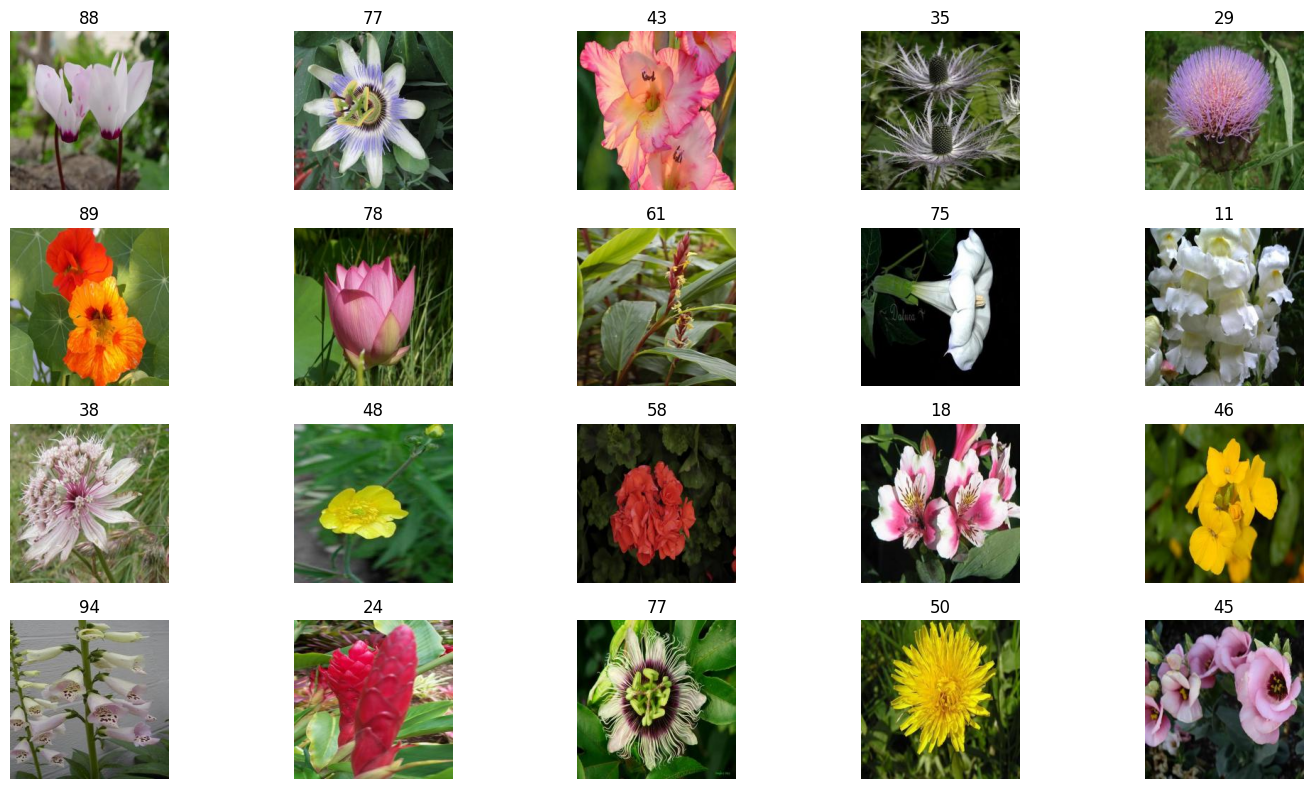

time: 1.54 s (started: 2025-05-21 13:12:57 +00:00)


In [9]:
#visualise a random samples, run this mulitple to view different sample sets
sampled_paths = random.sample(image_paths, 20)
show_images_in_grid(sampled_paths, sampled_paths, cols=5, figsize=(15, 8))

## Model fitting for classification
We will be utilizing **DINOv2**, a self-supervised Vision Transformer model developed by Meta AI, known for its ability to learn robust visual features from unlabeled images. DINOv2 serves as a powerful feature extractor, providing rich image representations. To adapt it for our specific task of classifying 102 flower categories, we will append a classification head — a linear layer that maps the extracted features to the desired number of classes.

**Data Preparation**:
Our dataset is organized into separate directories for training, validation, and testing. Within each of these, images are further divided into subfolders named after their corresponding class labels (ranging from 0 to 101). This structure is compatible with PyTorch's ImageFolder class, facilitating straightforward data loading and preprocessing.

**Loss Function**: Cross-Entropy Loss
Given that our task is multi-class classification, Cross-Entropy Loss is an appropriate choice. It measures the discrepancy between the predicted class probabilities and the actual class labels, effectively guiding the model to improve its predictions during training.​

Optimizer: AdamW

In [10]:
#imports
import torch
from transformers import AutoImageProcessor, AutoModel, AutoModelForImageClassification
from torchvision import transforms
from sklearn.metrics.pairwise import cosine_similarity

2025-05-21 13:13:13.895893: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747833194.096727      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747833194.155515      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


time: 27.2 s (started: 2025-05-21 13:13:01 +00:00)


In [11]:
#will train over GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

time: 2.4 ms (started: 2025-05-21 13:13:28 +00:00)


In [12]:
# Load the pre-trained DINOv2 model and processor
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
model = AutoModelForImageClassification.from_pretrained(
    "facebook/dinov2-base",
    num_labels=102  # Set this to the number of our classes
)

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


time: 6.31 s (started: 2025-05-21 13:13:28 +00:00)


In [13]:
#prepare data loader pipeline
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

batch_size = 64   #adjust based on GPU RAM
img_size = (224, 224)

train_data_path = '/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train'
valid_data_path = '/kaggle/input/flower-classification-dataset/Flower Classification Dataset/valid'
test_data_path = '/kaggle/input/flower-classification-dataset/Flower Classification Dataset/test'

# Define transformations
transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_data_path, transform=transform)
val_dataset = datasets.ImageFolder(root=valid_data_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_data_path, transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


time: 3.27 s (started: 2025-05-21 13:13:34 +00:00)


In [14]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score


# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

time: 1.41 ms (started: 2025-05-21 13:13:38 +00:00)


In [15]:
#move model to device->GPU
model.to(device)

best_val_loss = float('inf')
patience = 3
counter = 0

# Training loop
for epoch in range(7):  # Adjust the number of epochs as needed
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for step, (images, labels) in enumerate(train_loader, 1):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images).logits
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        running_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)

        # Log every 10 steps
        if step % 10 == 0:
            avg_loss = running_loss / 10
            avg_acc = running_correct / total_samples * 100
            print(f"Epoch [{epoch+1}], Step [{step}], Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.2f}%")
            running_loss = 0.0
            running_correct = 0
            total_samples = 0


        # Validate every x steps
        if step % 50 == 0:
            # Validation loop
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            all_preds = []
            all_labels = []

            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images).logits
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()
                    _, predicted = torch.max(outputs.data, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()
                    all_preds.extend(predicted.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())
            
            # Compute macro-averaged F1 score
            macro_f1 = f1_score(all_labels, all_preds, average='weighted')
            print(f"Epoch [{epoch+1}], Weighted-Averaged F1 Score: {macro_f1:.4f}")
        
            avg_val_loss = val_loss / len(val_loader)
            val_accuracy = val_correct / val_total * 100
            print(f"Epoch [{epoch+1}], Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")


            # Early stopping check
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                counter = 0
                torch.save(model.state_dict(), "best_model.pth")
                print("Saved new best model")
            else:
                counter += 1
                if counter >= patience:
                    print("Early stopping triggered")
                    break

Epoch [1], Step [10], Loss: 3.9580, Accuracy: 23.75%
Epoch [1], Step [20], Loss: 1.6374, Accuracy: 66.72%
Epoch [1], Step [30], Loss: 0.7125, Accuracy: 86.09%
Epoch [1], Step [40], Loss: 0.3026, Accuracy: 94.06%
Epoch [1], Step [50], Loss: 0.1566, Accuracy: 97.66%
Epoch [1], Weighted-Averaged F1 Score: 0.9795
Epoch [1], Validation Loss: 0.1230, Validation Accuracy: 97.95%
Saved new best model
Epoch [1], Step [60], Loss: 0.1170, Accuracy: 97.50%
Epoch [2], Step [10], Loss: 0.0392, Accuracy: 99.38%
Epoch [2], Step [20], Loss: 0.0541, Accuracy: 98.91%
Epoch [2], Step [30], Loss: 0.0385, Accuracy: 99.38%
Epoch [2], Step [40], Loss: 0.0163, Accuracy: 99.84%
Epoch [2], Step [50], Loss: 0.0252, Accuracy: 99.69%
Epoch [2], Weighted-Averaged F1 Score: 0.9810
Epoch [2], Validation Loss: 0.0821, Validation Accuracy: 98.09%
Saved new best model
Epoch [2], Step [60], Loss: 0.0200, Accuracy: 99.53%
Epoch [3], Step [10], Loss: 0.0134, Accuracy: 99.84%
Epoch [3], Step [20], Loss: 0.0064, Accuracy: 100

In [19]:
import torch
torch.save(model, "model.pth")

time: 782 ms (started: 2025-05-21 13:30:03 +00:00)


In [28]:
#load saved model
model_state_dict_path = "/kaggle/working/best_model.pth"
model = AutoModelForImageClassification.from_pretrained(
    "facebook/dinov2-base",
    num_labels=102  # Set this to the number of our classes
)
# Load the saved weights
model.load_state_dict(torch.load(model_state_dict_path, map_location=device))
model.to(device)

Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Dinov2ForImageClassification(
  (dinov2): Dinov2Model(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_scale1): Dinov2Laye

time: 944 ms (started: 2025-05-21 13:45:51 +00:00)


In [29]:
#set model to evaluation mode
model.eval()

# Calculate metrics over Test data
model.eval()
val_loss = 0.0
val_correct = 0
val_total = 0
all_preds = []
all_labels = []
misclassified_images = []
misclassified_preds = []
misclassified_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images).logits
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        misclassified_indices = (predicted != labels).nonzero(as_tuple=True)[0]
        # Store misclassified images and corresponding predictions and labels
        for idx in misclassified_indices:
            misclassified_images.append(images[idx].cpu())
            misclassified_preds.append(predicted[idx].cpu().item())
            misclassified_labels.append(labels[idx].cpu().item())

# Compute macro-averaged F1 score
macro_f1 = f1_score(all_labels, all_preds, average='weighted')
print(f"Weighted-Averaged F1 Score on Test Data: {macro_f1:.4f}")

avg_val_loss = val_loss / len(val_loader)
val_accuracy = val_correct / val_total * 100
print(f"Test data Loss: {avg_val_loss:.4f}, Test Data Accuracy: {val_accuracy:.2f}%")

Weighted-Averaged F1 Score on Test Data: 0.9961
Test data Loss: 0.0218, Test Data Accuracy: 99.61%
time: 20.5 s (started: 2025-05-21 13:45:58 +00:00)


Weighted-Averaged F1 Score on Test Data: 0.9961

Test data Loss: 0.0217, Test Data Accuracy: 99.61%

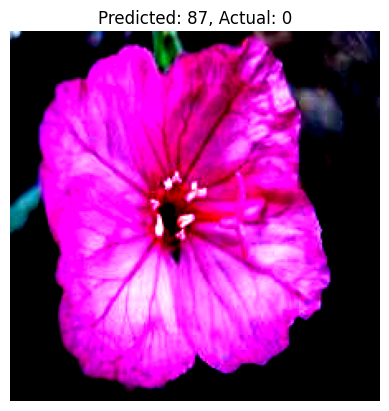

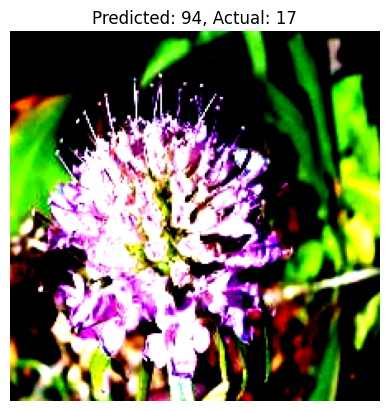

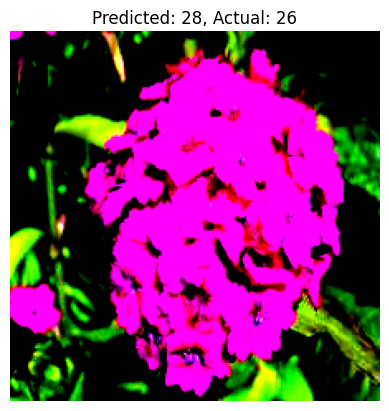

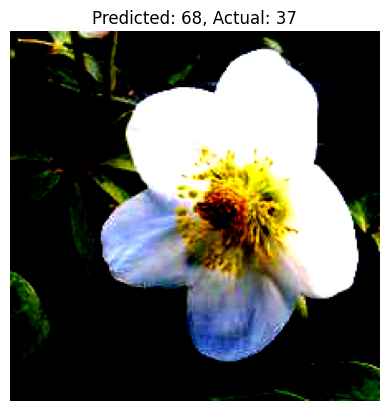

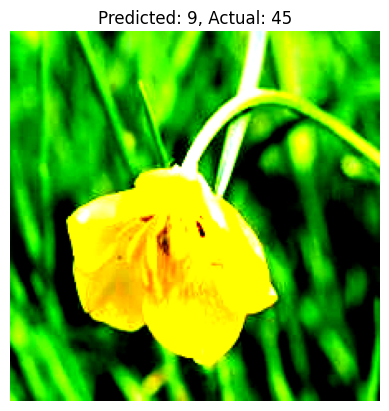

time: 1.01 s (started: 2025-05-21 13:46:24 +00:00)


In [30]:
import matplotlib.pyplot as plt

# Define the number of samples to display
num_samples = 5
for i in range(num_samples):
    image = misclassified_images[i]
    pred_label = misclassified_preds[i]
    true_label = misclassified_labels[i]
    # Convert the tensor to a NumPy array and transpose to (H, W, C)
    image_np = image.permute(1, 2, 0).numpy()
    # Denormalize if necessary
    # image_np = image_np * std + mean
    plt.imshow(image_np)
    plt.title(f"Predicted: {pred_label}, Actual: {true_label}")
    plt.axis('off')
    plt.show()
